In [18]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pickle
import scienceplots

plt.style.use(['science','no-latex', 'notebook'])
colors = ["#00BBF9", "#CC2836", "#F3A712","#3eb690","#A05496","#114b5f", "#8E3B46", "#D5E68D"]
markers = ['o-','s-','^-']
#mpl.rcParams.update(mpl.rcParamsDefault)

In [2]:
def compute_IGs(imbalances):    
    n_indep_realizations = imbalances.shape[0]
    n_eps = imbalances.shape[1]
    
    IGs_vs_alpha = 100*(imbalances[:,:,0,np.newaxis]-imbalances) / imbalances[:,:,0,np.newaxis]
    alphas_max = np.argmax(IGs_vs_alpha.mean(axis=0), axis=-1)

    IGs = IGs_vs_alpha.mean(axis=0)[np.arange(n_eps),alphas_max]
    errors = IGs_vs_alpha.std(axis=0)[np.arange(n_eps),alphas_max] / np.sqrt(n_indep_realizations)
    
    return IGs, errors

### Lorenz 96, all coordinates

In [5]:
seeds = np.arange(0.,31)
alphas = np.linspace(0.,1.5,300)
taus_forward = np.array([1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 60, 70, 80, 90, 100, 150, 200, 250, 300, 350, 400])
taus_backward = -np.flip(taus_forward)
taus = np.append(taus_backward,taus_forward)

# X and Y
info_imbalances_X_to_Y_eps1 = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_Y_to_X_eps1 = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_X_to_Y_eps3 = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_Y_to_X_eps3 = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_X_to_Y_obs = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_Y_to_X_obs = np.zeros((len(seeds),len(taus),len(alphas)))
for i_seed, seed in enumerate(seeds):
    _, info_imbalances_X_to_Y_eps1[i_seed], info_imbalances_Y_to_X_eps1[i_seed] = pickle.load(open(f"./ig_scripts/pickles_epszx_1/XY_seed{i_seed}.p","rb"))
    _, info_imbalances_X_to_Y_eps3[i_seed], info_imbalances_Y_to_X_eps3[i_seed] = pickle.load(open(f"./ig_scripts/pickles_epszx_3/XY_seed{i_seed}.p","rb"))
    _, info_imbalances_X_to_Y_obs[i_seed], info_imbalances_Y_to_X_obs[i_seed] = pickle.load(open(f"./ig_scripts/pickles_noZ/XY_seed{i_seed}.p","rb"))
IGs_X_to_Y_eps1, errors_X_to_Y_eps1 = compute_IGs(info_imbalances_X_to_Y_eps1)
IGs_Y_to_X_eps1, errors_Y_to_X_eps1 = compute_IGs(info_imbalances_Y_to_X_eps1)
IGs_X_to_Y_eps3, errors_X_to_Y_eps3 = compute_IGs(info_imbalances_X_to_Y_eps3)
IGs_Y_to_X_eps3, errors_Y_to_X_eps3 = compute_IGs(info_imbalances_Y_to_X_eps3)
IGs_X_to_Y_obs, errors_X_to_Y_obs = compute_IGs(info_imbalances_X_to_Y_obs)
IGs_Y_to_X_obs, errors_Y_to_X_obs = compute_IGs(info_imbalances_Y_to_X_obs)

# Z and Y
info_imbalances_Z_to_Y_eps1 = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_Y_to_Z_eps1 = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_Z_to_Y_eps3 = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_Y_to_Z_eps3 = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_Z_to_Y_obs = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_Y_to_Z_obs = np.zeros((len(seeds),len(taus),len(alphas)))
for i_seed, seed in enumerate(seeds):
    _, info_imbalances_Z_to_Y_eps1[i_seed], info_imbalances_Y_to_Z_eps1[i_seed] = pickle.load(open(f"./ig_scripts/pickles_epszx_1/ZY_seed{i_seed}.p","rb"))
    _, info_imbalances_Z_to_Y_eps3[i_seed], info_imbalances_Y_to_Z_eps3[i_seed] = pickle.load(open(f"./ig_scripts/pickles_epszx_3/ZY_seed{i_seed}.p","rb"))
    _, info_imbalances_Z_to_Y_obs[i_seed], info_imbalances_Y_to_Z_obs[i_seed] = pickle.load(open(f"./ig_scripts/pickles_noZ/ZY_seed{i_seed}.p","rb"))
IGs_Z_to_Y_eps1, errors_Z_to_Y_eps1 = compute_IGs(info_imbalances_Z_to_Y_eps1)
IGs_Y_to_Z_eps1, errors_Y_to_Z_eps1 = compute_IGs(info_imbalances_Y_to_Z_eps1)
IGs_Z_to_Y_eps3, errors_Z_to_Y_eps3 = compute_IGs(info_imbalances_Z_to_Y_eps3)
IGs_Y_to_Z_eps3, errors_Y_to_Z_eps3 = compute_IGs(info_imbalances_Y_to_Z_eps3)
IGs_Z_to_Y_obs, errors_Z_to_Y_obs = compute_IGs(info_imbalances_Z_to_Y_obs)
IGs_Y_to_Z_obs, errors_Y_to_Z_obs = compute_IGs(info_imbalances_Y_to_Z_obs)

# Z and X
info_imbalances_Z_to_X_eps1 = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_X_to_Z_eps1 = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_Z_to_X_eps3 = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_X_to_Z_eps3 = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_Z_to_X_obs = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_X_to_Z_obs = np.zeros((len(seeds),len(taus),len(alphas)))
for i_seed, seed in enumerate(seeds):
    _, info_imbalances_Z_to_X_eps1[i_seed], info_imbalances_X_to_Z_eps1[i_seed] = pickle.load(open(f"./ig_scripts/pickles_epszx_1/ZX_seed{i_seed}.p","rb"))
    _, info_imbalances_Z_to_X_eps3[i_seed], info_imbalances_X_to_Z_eps3[i_seed] = pickle.load(open(f"./ig_scripts/pickles_epszx_3/ZX_seed{i_seed}.p","rb"))
    _, info_imbalances_Z_to_X_obs[i_seed], info_imbalances_X_to_Z_obs[i_seed] = pickle.load(open(f"./ig_scripts/pickles_noZ/ZX_seed{i_seed}.p","rb"))
IGs_Z_to_X_eps1, errors_Z_to_X_eps1 = compute_IGs(info_imbalances_Z_to_X_eps1)
IGs_X_to_Z_eps1, errors_X_to_Z_eps1 = compute_IGs(info_imbalances_X_to_Z_eps1)
IGs_Z_to_X_eps3, errors_Z_to_X_eps3 = compute_IGs(info_imbalances_Z_to_X_eps3)
IGs_X_to_Z_eps3, errors_X_to_Z_eps3 = compute_IGs(info_imbalances_X_to_Z_eps3)
IGs_Z_to_X_obs, errors_Z_to_X_obs = compute_IGs(info_imbalances_Z_to_X_obs)
IGs_X_to_Z_obs, errors_X_to_Z_obs = compute_IGs(info_imbalances_X_to_Z_obs)

### plots

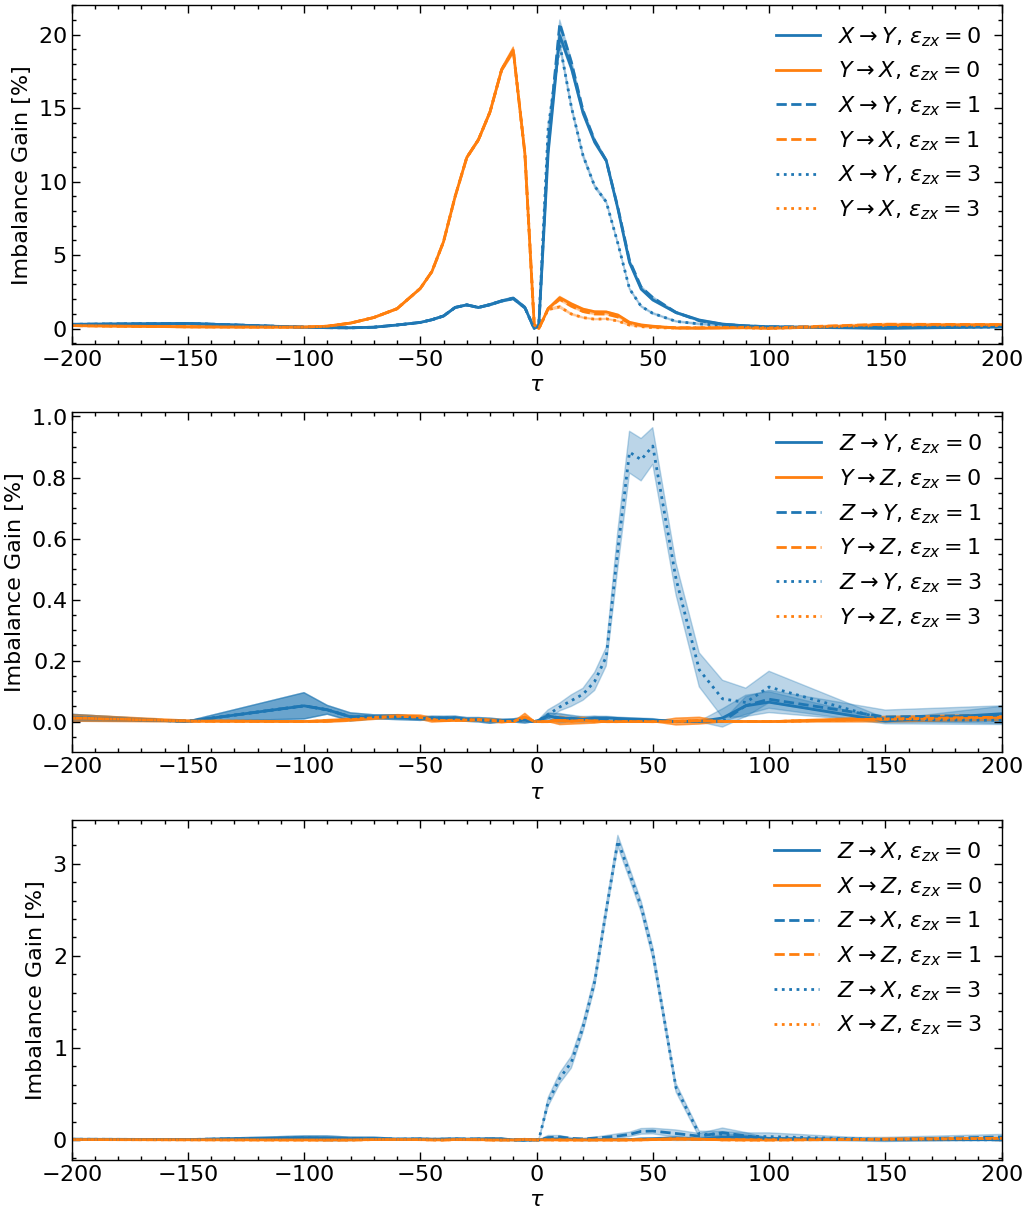

In [9]:
fig, ax = plt.subplots(3,1,figsize=(12,15))
n_skip = 1
n_half = len(taus) // 2

############################### X and Y ###############################
# eps_zx = 0
ax[0].plot(taus, IGs_X_to_Y_obs, '-', color="tab:blue", label="$X\\rightarrow Y$, $\\varepsilon_{zx}=0$")
ax[0].plot(taus, IGs_Y_to_X_obs, '-', color="tab:orange", label="$Y\\rightarrow X$, $\\varepsilon_{zx}=0$")
ax[0].fill_between(taus, IGs_X_to_Y_obs-errors_X_to_Y_obs, 
                    IGs_X_to_Y_obs+errors_X_to_Y_obs, color="tab:blue", alpha=0.3)
ax[0].fill_between(taus, IGs_Y_to_X_obs-errors_Y_to_X_obs, 
                    IGs_Y_to_X_obs+errors_Y_to_X_obs, color="tab:orange", alpha=0.3)
# eps_zx = 1
ax[0].plot(taus, IGs_X_to_Y_eps1, '--', color="tab:blue", label="$X\\rightarrow Y$, $\\varepsilon_{zx}=1$")
ax[0].plot(taus, IGs_Y_to_X_eps1, '--', color="tab:orange", label="$Y\\rightarrow X$, $\\varepsilon_{zx}=1$")
ax[0].fill_between(taus, IGs_X_to_Y_eps1-errors_X_to_Y_eps1, 
                   IGs_X_to_Y_eps1+errors_X_to_Y_eps1, color="tab:blue", alpha=0.3)
ax[0].fill_between(taus, IGs_Y_to_X_eps1-errors_Y_to_X_eps1, 
                   IGs_Y_to_X_eps1+errors_Y_to_X_eps1, color="tab:orange", alpha=0.3)
# eps_zx = 3
ax[0].plot(taus, IGs_X_to_Y_eps3, ':', color="tab:blue", label="$X\\rightarrow Y$, $\\varepsilon_{zx}=3$")
ax[0].plot(taus, IGs_Y_to_X_eps3, ':', color="tab:orange", label="$Y\\rightarrow X$, $\\varepsilon_{zx}=3$")
ax[0].fill_between(taus, IGs_X_to_Y_eps3-errors_X_to_Y_eps3, 
                   IGs_X_to_Y_eps3+errors_X_to_Y_eps3, color="tab:blue", alpha=0.3)
ax[0].fill_between(taus, IGs_Y_to_X_eps3-errors_Y_to_X_eps3, 
                   IGs_Y_to_X_eps3+errors_Y_to_X_eps3, color="tab:orange", alpha=0.3)
ax[0].set(xlabel="$\\tau$", ylabel="Imbalance Gain [%]", xlim=[-200,200])
ax[0].legend()

################################ Z and X ###############################
# eps_zx = 0
ax[2].plot(taus, IGs_Z_to_X_obs, '-', color="tab:blue", label="$Z\\rightarrow X$, $\\varepsilon_{zx}=0$")
ax[2].plot(taus, IGs_X_to_Z_obs, '-', color="tab:orange", label="$X\\rightarrow Z$, $\\varepsilon_{zx}=0$")
ax[2].fill_between(taus, IGs_Z_to_X_obs-errors_Z_to_X_obs, 
                   IGs_Z_to_X_obs+errors_Z_to_X_obs, color="tab:blue", alpha=0.3)
ax[2].fill_between(taus, IGs_X_to_Z_obs-errors_X_to_Z_obs, 
                   IGs_X_to_Z_obs+errors_X_to_Z_obs, color="tab:orange", alpha=0.3)
# eps_zx = 1
ax[2].plot(taus, IGs_Z_to_X_eps1, '--', color="tab:blue", label="$Z\\rightarrow X$, $\\varepsilon_{zx}=1$")
ax[2].plot(taus, IGs_X_to_Z_eps1, '--', color="tab:orange", label="$X\\rightarrow Z$, $\\varepsilon_{zx}=1$")
ax[2].fill_between(taus, IGs_Z_to_X_eps1-errors_Z_to_X_eps1, 
                   IGs_Z_to_X_eps1+errors_Z_to_X_eps1, color="tab:blue", alpha=0.3)
ax[2].fill_between(taus, IGs_X_to_Z_eps1-errors_X_to_Z_eps1, 
                   IGs_X_to_Z_eps1+errors_X_to_Z_eps1, color="tab:orange", alpha=0.3)
# eps_zx = 3
ax[2].plot(taus, IGs_Z_to_X_eps3, ':', color="tab:blue", label="$Z\\rightarrow X$, $\\varepsilon_{zx}=3$")
ax[2].plot(taus, IGs_X_to_Z_eps3, ':', color="tab:orange", label="$X\\rightarrow Z$, $\\varepsilon_{zx}=3$")
ax[2].fill_between(taus, IGs_Z_to_X_eps3-errors_Z_to_X_eps3, 
                   IGs_Z_to_X_eps3+errors_Z_to_X_eps3, color="tab:blue", alpha=0.3)
ax[2].fill_between(taus, IGs_X_to_Z_eps3-errors_X_to_Z_eps3, 
                   IGs_X_to_Z_eps3+errors_X_to_Z_eps3, color="tab:orange", alpha=0.3)
ax[2].set(xlabel="$\\tau$", ylabel="Imbalance Gain [%]",xlim=[-200,200])
ax[2].legend()

################################ Z and Y ###############################
# eps_zx = 0
ax[1].plot(taus, IGs_Z_to_Y_obs, '-', color="tab:blue", label="$Z\\rightarrow Y$, $\\varepsilon_{zx}=0$")
ax[1].plot(taus, IGs_Y_to_Z_obs, '-', color="tab:orange", label="$Y\\rightarrow Z$, $\\varepsilon_{zx}=0$")
ax[1].fill_between(taus, IGs_Z_to_Y_obs-errors_Z_to_Y_obs, 
                   IGs_Z_to_Y_obs+errors_Z_to_Y_obs, color="tab:blue", alpha=0.3)
ax[1].fill_between(taus, IGs_Y_to_Z_obs-errors_Y_to_Z_obs, 
                   IGs_Y_to_Z_obs+errors_Y_to_Z_obs, color="tab:orange", alpha=0.3)
# eps_zx = 1
ax[1].plot(taus, IGs_Z_to_Y_eps1, '--', color="tab:blue", label="$Z\\rightarrow Y$, $\\varepsilon_{zx}=1$")
ax[1].plot(taus, IGs_Y_to_Z_eps1, '--', color="tab:orange", label="$Y\\rightarrow Z$, $\\varepsilon_{zx}=1$")
ax[1].fill_between(taus, IGs_Z_to_Y_eps1-errors_Z_to_Y_eps1, 
                   IGs_Z_to_Y_eps1+errors_Z_to_Y_eps1, color="tab:blue", alpha=0.3)
ax[1].fill_between(taus, IGs_Y_to_Z_eps1-errors_Y_to_Z_eps1, 
                   IGs_Y_to_Z_eps1+errors_Y_to_Z_eps1, color="tab:orange", alpha=0.3)
# eps_zx = 3
ax[1].plot(taus, IGs_Z_to_Y_eps3, ':', color="tab:blue", label="$Z\\rightarrow Y$, $\\varepsilon_{zx}=3$")
ax[1].plot(taus, IGs_Y_to_Z_eps3, ':', color="tab:orange", label="$Y\\rightarrow Z$, $\\varepsilon_{zx}=3$")
ax[1].fill_between(taus, IGs_Z_to_Y_eps3-errors_Z_to_Y_eps3, 
                   IGs_Z_to_Y_eps3+errors_Z_to_Y_eps3, color="tab:blue", alpha=0.3)
ax[1].fill_between(taus, IGs_Y_to_Z_eps3-errors_Y_to_Z_eps3, 
                   IGs_Y_to_Z_eps3+errors_Y_to_Z_eps3, color="tab:orange", alpha=0.3)
ax[1].set(xlabel="$\\tau$", ylabel="Imbalance Gain [%]", xlim=[-200,200])
ax[1].legend()

plt.savefig("./figures/window_z.pdf", dpi=300)
plt.show()

### Lorenz 96, more neighbors

In [3]:
seeds = np.arange(0.,31)
alphas = np.linspace(0.,1.5,300)
taus_forward = np.array([1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 60, 70, 80, 90, 100, 150, 200, 250, 300, 350, 400])
taus_backward = -np.flip(taus_forward)
taus = np.append(taus_backward,taus_forward)

In [4]:
# X and Y
info_imbalances_X_to_Y_2 = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_Y_to_X_2 = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_X_to_Y_5 = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_Y_to_X_5 = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_X_to_Y_10 = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_Y_to_X_10 = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_X_to_Y_20 = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_Y_to_X_20 = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_X_to_Y_obs = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_Y_to_X_obs = np.zeros((len(seeds),len(taus),len(alphas)))
for i_seed, seed in enumerate(seeds):
    _, info_imbalances_X_to_Y_2[i_seed], info_imbalances_Y_to_X_2[i_seed] = pickle.load(open(f"./ig_scripts/pickles_epszx_3/XY_seed{i_seed}.p","rb"))
    _, info_imbalances_X_to_Y_5[i_seed], info_imbalances_Y_to_X_5[i_seed] = pickle.load(open(f"./ig_scripts_more_neighbors/pickles_epszx_3/XY5_seed{i_seed}.p","rb"))
    _, info_imbalances_X_to_Y_10[i_seed], info_imbalances_Y_to_X_10[i_seed] = pickle.load(open(f"./ig_scripts_more_neighbors/pickles_epszx_3/XY10_seed{i_seed}.p","rb"))
    _, info_imbalances_X_to_Y_20[i_seed], info_imbalances_Y_to_X_20[i_seed] = pickle.load(open(f"./ig_scripts_more_neighbors/pickles_epszx_3/XY20_seed{i_seed}.p","rb"))
    _, info_imbalances_X_to_Y_obs[i_seed], info_imbalances_Y_to_X_obs[i_seed] = pickle.load(open(f"./ig_scripts/pickles_noZ/XY_seed{i_seed}.p","rb"))
IGs_X_to_Y_2, errors_X_to_Y_2 = compute_IGs(info_imbalances_X_to_Y_2)
IGs_Y_to_X_2, errors_Y_to_X_2 = compute_IGs(info_imbalances_Y_to_X_2)
IGs_X_to_Y_5, errors_X_to_Y_5 = compute_IGs(info_imbalances_X_to_Y_5)
IGs_Y_to_X_5, errors_Y_to_X_5 = compute_IGs(info_imbalances_Y_to_X_5)
IGs_X_to_Y_10, errors_X_to_Y_10 = compute_IGs(info_imbalances_X_to_Y_10)
IGs_Y_to_X_10, errors_Y_to_X_10 = compute_IGs(info_imbalances_Y_to_X_10)
IGs_X_to_Y_20, errors_X_to_Y_20 = compute_IGs(info_imbalances_X_to_Y_20)
IGs_Y_to_X_20, errors_Y_to_X_20 = compute_IGs(info_imbalances_Y_to_X_20)
IGs_X_to_Y_obs, errors_X_to_Y_obs = compute_IGs(info_imbalances_X_to_Y_obs)
IGs_Y_to_X_obs, errors_Y_to_X_obs = compute_IGs(info_imbalances_Y_to_X_obs)

# Z and Y
info_imbalances_Z_to_Y_2 = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_Y_to_Z_2 = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_Z_to_Y_5 = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_Y_to_Z_5 = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_Z_to_Y_10 = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_Y_to_Z_10 = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_Z_to_Y_20 = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_Y_to_Z_20 = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_Z_to_Y_obs = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_Y_to_Z_obs = np.zeros((len(seeds),len(taus),len(alphas)))
for i_seed, seed in enumerate(seeds):
    _, info_imbalances_Z_to_Y_2[i_seed], info_imbalances_Y_to_Z_2[i_seed] = pickle.load(open(f"./ig_scripts/pickles_epszx_3/ZY_seed{i_seed}.p","rb"))
    _, info_imbalances_Z_to_Y_5[i_seed], info_imbalances_Y_to_Z_5[i_seed] = pickle.load(open(f"./ig_scripts_more_neighbors/pickles_epszx_3/ZY5_seed{i_seed}.p","rb"))
    _, info_imbalances_Z_to_Y_10[i_seed], info_imbalances_Y_to_Z_10[i_seed] = pickle.load(open(f"./ig_scripts_more_neighbors/pickles_epszx_3/ZY10_seed{i_seed}.p","rb"))
    _, info_imbalances_Z_to_Y_20[i_seed], info_imbalances_Y_to_Z_20[i_seed] = pickle.load(open(f"./ig_scripts_more_neighbors/pickles_epszx_3/ZY20_seed{i_seed}.p","rb"))
    _, info_imbalances_Z_to_Y_obs[i_seed], info_imbalances_Y_to_Z_obs[i_seed] = pickle.load(open(f"./ig_scripts/pickles_noZ/ZY_seed{i_seed}.p","rb"))
IGs_Z_to_Y_2, errors_Z_to_Y_2 = compute_IGs(info_imbalances_Z_to_Y_2)
IGs_Y_to_Z_2, errors_Y_to_Z_2 = compute_IGs(info_imbalances_Y_to_Z_2)
IGs_Z_to_Y_5, errors_Z_to_Y_5 = compute_IGs(info_imbalances_Z_to_Y_5)
IGs_Y_to_Z_5, errors_Y_to_Z_5 = compute_IGs(info_imbalances_Y_to_Z_5)
IGs_Z_to_Y_10, errors_Z_to_Y_10 = compute_IGs(info_imbalances_Z_to_Y_10)
IGs_Y_to_Z_10, errors_Y_to_Z_10 = compute_IGs(info_imbalances_Y_to_Z_10)
IGs_Z_to_Y_20, errors_Z_to_Y_20 = compute_IGs(info_imbalances_Z_to_Y_20)
IGs_Y_to_Z_20, errors_Y_to_Z_20 = compute_IGs(info_imbalances_Y_to_Z_20)
IGs_Z_to_Y_obs, errors_Z_to_Y_obs = compute_IGs(info_imbalances_Z_to_Y_obs)
IGs_Y_to_Z_obs, errors_Y_to_Z_obs = compute_IGs(info_imbalances_Y_to_Z_obs)

In [6]:
# X and Y
info_imbalances_X_to_Y_obs2 = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_Y_to_X_obs2 = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_X_to_Y_obs5 = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_Y_to_X_obs5 = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_X_to_Y_obs10 = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_Y_to_X_obs10 = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_X_to_Y_obs20 = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_Y_to_X_obs20 = np.zeros((len(seeds),len(taus),len(alphas)))
for i_seed, seed in enumerate(seeds):
    _, info_imbalances_X_to_Y_obs2[i_seed], info_imbalances_Y_to_X_obs2[i_seed] = pickle.load(open(f"./ig_scripts/pickles_noZ/XY_seed{i_seed}.p","rb"))
    _, info_imbalances_X_to_Y_obs5[i_seed], info_imbalances_Y_to_X_obs5[i_seed] = pickle.load(open(f"./ig_scripts_more_neighbors/pickles_noZ/XY5_seed{i_seed}.p","rb"))
    _, info_imbalances_X_to_Y_obs10[i_seed], info_imbalances_Y_to_X_obs10[i_seed] = pickle.load(open(f"./ig_scripts_more_neighbors/pickles_noZ/XY10_seed{i_seed}.p","rb"))
    _, info_imbalances_X_to_Y_obs20[i_seed], info_imbalances_Y_to_X_obs20[i_seed] = pickle.load(open(f"./ig_scripts_more_neighbors/pickles_noZ/XY20_seed{i_seed}.p","rb"))
IGs_X_to_Y_obs2,  errors_X_to_Y_obs2 =  compute_IGs(info_imbalances_X_to_Y_obs2)
IGs_Y_to_X_obs2,  errors_Y_to_X_obs2 =  compute_IGs(info_imbalances_Y_to_X_obs2)
IGs_X_to_Y_obs5,  errors_X_to_Y_obs5 =  compute_IGs(info_imbalances_X_to_Y_obs5)
IGs_Y_to_X_obs5,  errors_Y_to_X_obs5 =  compute_IGs(info_imbalances_Y_to_X_obs5)
IGs_X_to_Y_obs10, errors_X_to_Y_obs10 = compute_IGs(info_imbalances_X_to_Y_obs10)
IGs_Y_to_X_obs10, errors_Y_to_X_obs10 = compute_IGs(info_imbalances_Y_to_X_obs10)
IGs_X_to_Y_obs20, errors_X_to_Y_obs20 = compute_IGs(info_imbalances_X_to_Y_obs20)
IGs_Y_to_X_obs20, errors_Y_to_X_obs20 = compute_IGs(info_imbalances_Y_to_X_obs20)

# Z and Y
info_imbalances_Z_to_Y_obs2 = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_Y_to_Z_obs2 = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_Z_to_Y_obs5 = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_Y_to_Z_obs5 = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_Z_to_Y_obs10 = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_Y_to_Z_obs10 = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_Z_to_Y_obs20 = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_Y_to_Z_obs20 = np.zeros((len(seeds),len(taus),len(alphas)))
for i_seed, seed in enumerate(seeds):
    _, info_imbalances_Z_to_Y_obs2[i_seed], info_imbalances_Y_to_Z_obs2[i_seed] = pickle.load(open(f"./ig_scripts/pickles_noZ/ZY_seed{i_seed}.p","rb"))
    _, info_imbalances_Z_to_Y_obs5[i_seed], info_imbalances_Y_to_Z_obs5[i_seed] = pickle.load(open(f"./ig_scripts_more_neighbors/pickles_noZ/ZY5_seed{i_seed}.p","rb"))
    _, info_imbalances_Z_to_Y_obs10[i_seed], info_imbalances_Y_to_Z_obs10[i_seed] = pickle.load(open(f"./ig_scripts_more_neighbors/pickles_noZ/ZY10_seed{i_seed}.p","rb"))
    _, info_imbalances_Z_to_Y_obs20[i_seed], info_imbalances_Y_to_Z_obs20[i_seed] = pickle.load(open(f"./ig_scripts_more_neighbors/pickles_noZ/ZY20_seed{i_seed}.p","rb"))
IGs_Z_to_Y_obs2,  errors_Z_to_Y_obs2 =  compute_IGs(info_imbalances_Z_to_Y_obs2)
IGs_Y_to_Z_obs2,  errors_Y_to_Z_obs2 =  compute_IGs(info_imbalances_Y_to_Z_obs2)
IGs_Z_to_Y_obs5,  errors_Z_to_Y_obs5 =  compute_IGs(info_imbalances_Z_to_Y_obs5)
IGs_Y_to_Z_obs5,  errors_Y_to_Z_obs5 =  compute_IGs(info_imbalances_Y_to_Z_obs5)
IGs_Z_to_Y_obs10, errors_Z_to_Y_obs10 = compute_IGs(info_imbalances_Z_to_Y_obs10)
IGs_Y_to_Z_obs10, errors_Y_to_Z_obs10 = compute_IGs(info_imbalances_Y_to_Z_obs10)
IGs_Z_to_Y_obs20, errors_Z_to_Y_obs20 = compute_IGs(info_imbalances_Z_to_Y_obs20)
IGs_Y_to_Z_obs20, errors_Y_to_Z_obs20 = compute_IGs(info_imbalances_Y_to_Z_obs20)

### plots

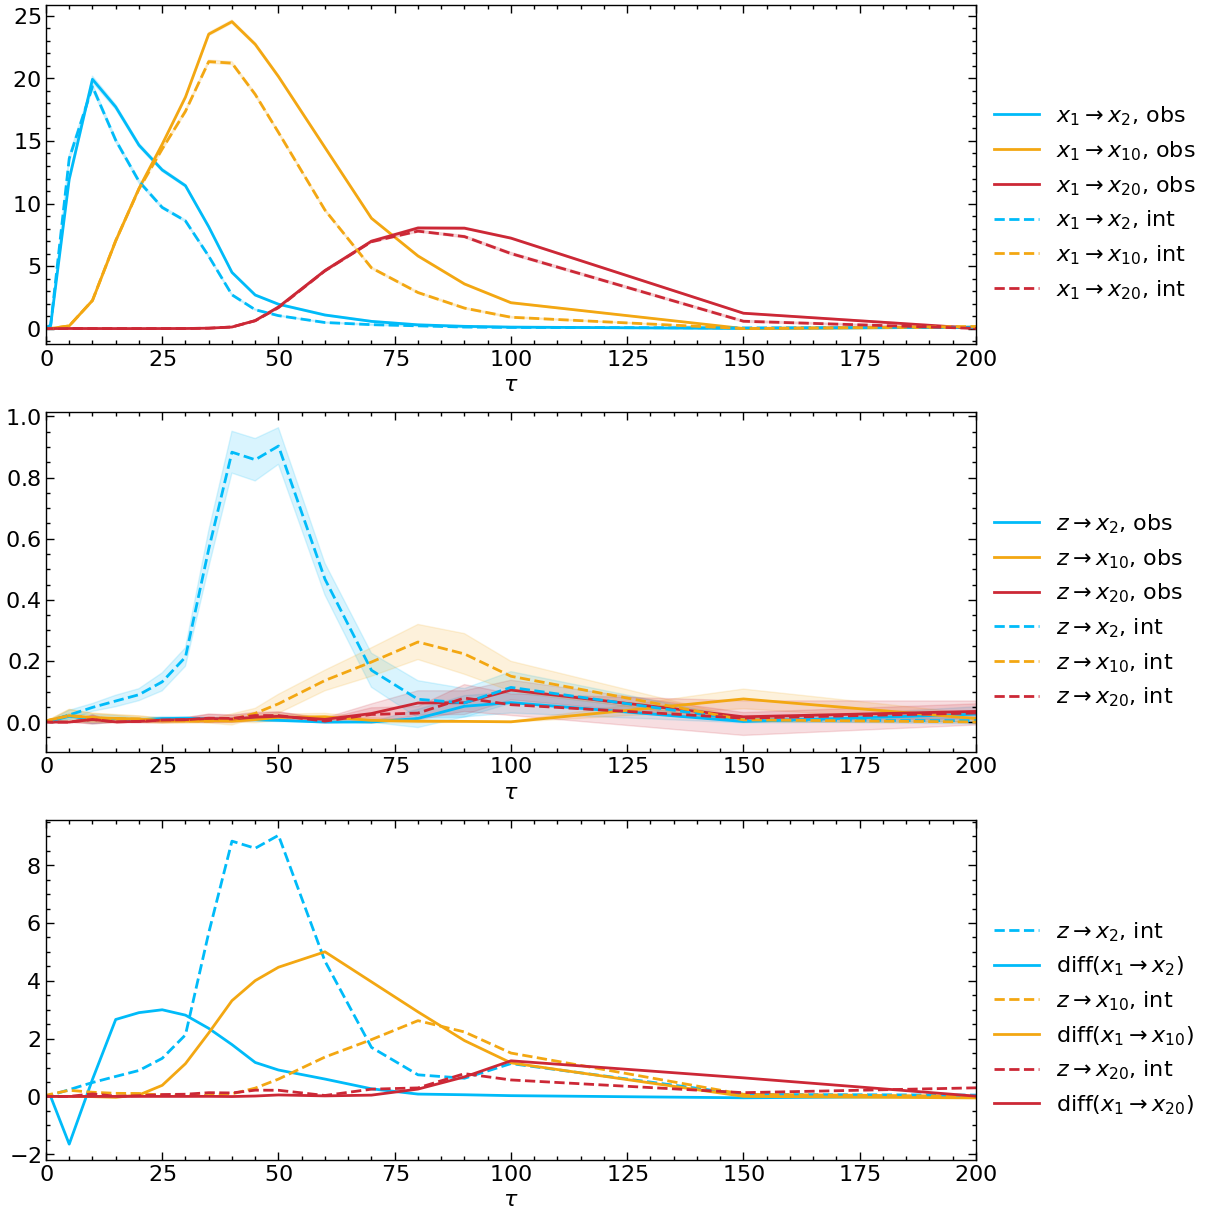

In [25]:
fig, ax = plt.subplots(3,1,figsize=(12,15))
n_skip = 1
n_half = len(taus) // 2

############################### X and Y ###############################
# observational
# Y=x_2
ax[0].plot(taus, IGs_X_to_Y_obs2, '-', color=colors[0], label="$x_1\\rightarrow x_2$, obs")
#ax[0].plot(taus, IGs_Y_to_X_obs2, '--', color=colors[0], label="$x_2\\rightarrow x_1$")
ax[0].fill_between(taus, IGs_X_to_Y_obs2-errors_X_to_Y_obs2, 
                         IGs_X_to_Y_obs2+errors_X_to_Y_obs2, color=colors[0], alpha=0.15)
#ax[0].fill_between(taus, IGs_Y_to_X_obs2-errors_Y_to_X_obs2, 
#                         IGs_Y_to_X_obs2+errors_Y_to_X_obs2, color=colors[0], alpha=0.15)
# Y=x_5
#ax[0].plot(taus, IGs_X_to_Y_obs5, '-', color=colors[1], label="$x_1\\rightarrow x_5$")
#ax[0].plot(taus, IGs_Y_to_X_obs5, '--', color=colors[1], label="$x_5\\rightarrow x_1$")
#ax[0].fill_between(taus, IGs_X_to_Y_obs5-errors_X_to_Y_obs5, 
#                         IGs_X_to_Y_obs5+errors_X_to_Y_obs5, color=colors[1], alpha=0.15)
#ax[0].fill_between(taus, IGs_Y_to_X_obs5-errors_Y_to_X_obs5, 
#                         IGs_Y_to_X_obs5+errors_Y_to_X_obs5, color=colors[1], alpha=0.15)
# Y=x_10
ax[0].plot(taus, IGs_X_to_Y_obs10, '-', color=colors[2], label="$x_1\\rightarrow x_{10}$, obs")
#ax[0].plot(taus, IGs_Y_to_X_obs10, '--', color=colors[2], label="$x_{10}\\rightarrow x_1$")
ax[0].fill_between(taus, IGs_X_to_Y_obs10-errors_X_to_Y_obs10, 
                         IGs_X_to_Y_obs10+errors_X_to_Y_obs10, color=colors[2], alpha=0.15)
#ax[0].fill_between(taus, IGs_Y_to_X_obs10-errors_Y_to_X_obs10, 
#                         IGs_Y_to_X_obs10+errors_Y_to_X_obs10, color=colors[2], alpha=0.15)
# Y=x_20
ax[0].plot(taus, IGs_X_to_Y_obs20, '-', color=colors[1], label="$x_1\\rightarrow x_{20}$, obs")
#ax[0].plot(taus, IGs_Y_to_X_obs20, '--', color=colors[3], label="$x_{20}\\rightarrow x_1$")
ax[0].fill_between(taus, IGs_X_to_Y_obs20-errors_X_to_Y_obs20, 
                         IGs_X_to_Y_obs20+errors_X_to_Y_obs20, color=colors[1], alpha=0.15)
#ax[0].fill_between(taus, IGs_Y_to_X_obs20-errors_Y_to_X_obs20, 
#                         IGs_Y_to_X_obs20+errors_Y_to_X_obs20, color=colors[3], alpha=0.15)
# interventional
# Y=x_2
ax[0].plot(taus, IGs_X_to_Y_2, '--', color=colors[0], label="$x_1\\rightarrow x_2$, int")
#ax[0].plot(taus, IGs_Y_to_X_2, '--', color=colors[0], label="$x_2\\rightarrow x_1$")
ax[0].fill_between(taus, IGs_X_to_Y_2-errors_X_to_Y_2, 
                         IGs_X_to_Y_2+errors_X_to_Y_2, color=colors[0], alpha=0.15)
#ax[0].fill_between(taus, IGs_Y_to_X_2-errors_Y_to_X_2, 
#                         IGs_Y_to_X_2+errors_Y_to_X_2, color=colors[0], alpha=0.15)
# Y=x_5
#ax[0].plot(taus, IGs_X_to_Y_5, '--', color=colors[1], label="$x_1\\rightarrow x_5$")
#ax[0].plot(taus, IGs_Y_to_X_5, '--', color=colors[1], label="$x_5\\rightarrow x_1$")
#ax[0].fill_between(taus, IGs_X_to_Y_5-errors_X_to_Y_5, 
#                         IGs_X_to_Y_5+errors_X_to_Y_5, color=colors[1], alpha=0.15)
#ax[0].fill_between(taus, IGs_Y_to_X_5-errors_Y_to_X_5, 
#                         IGs_Y_to_X_5+errors_Y_to_X_5, color=colors[1], alpha=0.15)
# Y=x_10
ax[0].plot(taus, IGs_X_to_Y_10, '--', color=colors[2], label="$x_1\\rightarrow x_{10}$, int")
#ax[0].plot(taus, IGs_Y_to_X_10, '--', color=colors[2], label="$x_{10}\\rightarrow x_1$")
ax[0].fill_between(taus, IGs_X_to_Y_10-errors_X_to_Y_10, 
                         IGs_X_to_Y_10+errors_X_to_Y_10, color=colors[2], alpha=0.15)
#ax[0].fill_between(taus, IGs_Y_to_X_10-errors_Y_to_X_10, 
#                         IGs_Y_to_X_10+errors_Y_to_X_10, color=colors[2], alpha=0.15)
# Y=x_20
ax[0].plot(taus, IGs_X_to_Y_20, '--', color=colors[1], label="$x_1\\rightarrow x_{20}$, int")
#ax[0].plot(taus, IGs_Y_to_X_20, '--', color=colors[3], label="$x_{20}\\rightarrow x_1$")
ax[0].fill_between(taus, IGs_X_to_Y_20-errors_X_to_Y_20, 
                         IGs_X_to_Y_20+errors_X_to_Y_20, color=colors[1], alpha=0.15)
#ax[0].fill_between(taus, IGs_Y_to_X_20-errors_Y_to_X_20, 
#                         IGs_Y_to_X_20+errors_Y_to_X_20, color=colors[3], alpha=0.15)

ax[0].legend(loc=(1.01,0.1))
ax[0].set(xlim=[-0,200], xlabel="$\\tau$", ylabel="Imbalance Gain [%]")


################################ Z and Y ###############################
# observational
# Y=x_2
ax[1].plot(taus, IGs_Z_to_Y_obs2, '-', color=colors[0], label="$z\\rightarrow x_2$, obs")
#ax[1].plot(taus, IGs_Y_to_Z_obs2, '--', color=colors[0], label="$x_2\\rightarrow z$")
ax[1].fill_between(taus, IGs_Z_to_Y_obs2-errors_Z_to_Y_obs2, 
                         IGs_Z_to_Y_obs2+errors_Z_to_Y_obs2, color=colors[0], alpha=0.15)
#ax[1].fill_between(taus, IGs_Y_to_Z_obs2-errors_Y_to_Z_obs2, 
#                         IGs_Y_to_Z_obs2+errors_Y_to_Z_obs2, color=colors[0], alpha=0.15)
# Y=x_5
#ax[1].plot(taus, IGs_Z_to_Y_obs5, '-', color=colors[1], label="$z\\rightarrow x_5$")
#ax[1].plot(taus, IGs_Y_to_Z_obs5, '--', color=colors[1], label="$x_5\\rightarrow z$")
#ax[1].fill_between(taus, IGs_Z_to_Y_obs5-errors_Z_to_Y_obs5, 
#                         IGs_Z_to_Y_obs5+errors_Z_to_Y_obs5, color=colors[1], alpha=0.15)
#ax[1].fill_between(taus, IGs_Y_to_Z_obs5-errors_Y_to_Z_obs5, 
#                         IGs_Y_to_Z_obs5+errors_Y_to_Z_obs5, color=colors[1], alpha=0.15)
# Y=x_10
ax[1].plot(taus, IGs_Z_to_Y_obs10, '-', color=colors[2], label="$z\\rightarrow x_{10}$, obs")
#ax[1].plot(taus, IGs_Y_to_Z_obs10, '--', color=colors[2], label="$x_{10}\\rightarrow z$")
ax[1].fill_between(taus, IGs_Z_to_Y_obs10-errors_Z_to_Y_obs10, 
                         IGs_Z_to_Y_obs10+errors_Z_to_Y_obs10, color=colors[2], alpha=0.15)
#ax[1].fill_between(taus, IGs_Y_to_Z_obs10-errors_Y_to_Z_obs10, 
#                         IGs_Y_to_Z_obs10+errors_Y_to_Z_obs10, color=colors[2], alpha=0.15)
# Y=x_20
ax[1].plot(taus, IGs_Z_to_Y_obs20, '-', color=colors[1], label="$z\\rightarrow x_{20}$, obs")
#ax[1].plot(taus, IGs_Y_to_Z_obs20, '--', color=colors[3], label="$x_{20}\\rightarrow z$")
ax[1].fill_between(taus, IGs_Z_to_Y_obs20-errors_Z_to_Y_obs20, 
                         IGs_Z_to_Y_obs20+errors_Z_to_Y_obs20, color=colors[1], alpha=0.15)
#ax[1].fill_between(taus, IGs_Y_to_Z_obs20-errors_Y_to_Z_obs20, 
#                         IGs_Y_to_Z_obs20+errors_Y_to_Z_obs20, color=colors[3], alpha=0.15)
# interventional
# Y=x_2
ax[1].plot(taus, IGs_Z_to_Y_2, '--', color=colors[0], label="$z\\rightarrow x_2$, int")
#ax[1].plot(taus, IGs_Y_to_Z_2, '--', color=colors[0], label="$x_2\\rightarrow z$")
ax[1].fill_between(taus, IGs_Z_to_Y_2-errors_Z_to_Y_2, 
                         IGs_Z_to_Y_2+errors_Z_to_Y_2, color=colors[0], alpha=0.15)
#ax[1].fill_between(taus, IGs_Y_to_Z_2-errors_Y_to_Z_2, 
#                         IGs_Y_to_Z_2+errors_Y_to_Z_2, color=colors[0], alpha=0.15)
# Y=x_5
#ax[1].plot(taus, IGs_Z_to_Y_5, '--', color=colors[1], label="$z\\rightarrow x_5$")
#ax[1].plot(taus, IGs_Y_to_Z_5, '--', color=colors[1], label="$x_5\\rightarrow z$")
#ax[1].fill_between(taus, IGs_Z_to_Y_5-errors_Z_to_Y_5, 
#                         IGs_Z_to_Y_5+errors_Z_to_Y_5, color=colors[1], alpha=0.15)
#ax[1].fill_between(taus, IGs_Y_to_Z_5-errors_Y_to_Z_5, 
#                         IGs_Y_to_Z_5+errors_Y_to_Z_5, color=colors[1], alpha=0.15)
# Y=x_10
ax[1].plot(taus, IGs_Z_to_Y_10, '--', color=colors[2], label="$z\\rightarrow x_{10}$, int")
#ax[1].plot(taus, IGs_Y_to_Z_10, '--', color=colors[2], label="$x_{10}\\rightarrow z$")
ax[1].fill_between(taus, IGs_Z_to_Y_10-errors_Z_to_Y_10, 
                         IGs_Z_to_Y_10+errors_Z_to_Y_10, color=colors[2], alpha=0.15)
#ax[1].fill_between(taus, IGs_Y_to_Z_10-errors_Y_to_Z_10, 
#                         IGs_Y_to_Z_10+errors_Y_to_Z_10, color=colors[2], alpha=0.15)
# Y=x_20
ax[1].plot(taus, IGs_Z_to_Y_20, '--', color=colors[1], label="$z\\rightarrow x_{20}$, int")
#ax[1].plot(taus, IGs_Y_to_Z_20, '--', color=colors[3], label="$x_{20}\\rightarrow z$")
ax[1].fill_between(taus, IGs_Z_to_Y_20-errors_Z_to_Y_20, 
                         IGs_Z_to_Y_20+errors_Z_to_Y_20, color=colors[1], alpha=0.15)
#ax[1].fill_between(taus, IGs_Y_to_Z_20-errors_Y_to_Z_20, 
#                         IGs_Y_to_Z_20+errors_Y_to_Z_20, color=colors[3], alpha=0.15)
ax[1].legend(loc=(1.01,0.1))
ax[1].set(xlim=[-0,200], xlabel="$\\tau$", ylabel="Imbalance Gain [%]")


################################ Z->Y vs diff(X->Y) ###############################
# interventional
# Y=x_2
ax[2].plot(taus, 10*IGs_Z_to_Y_2, '--', color=colors[0], label="$z\\rightarrow x_2$, int")
ax[2].plot(taus, IGs_X_to_Y_obs2-IGs_X_to_Y_2, '-', color=colors[0], label="diff($x_1\\rightarrow x_2$)")

# Y=x_5
#ax[2].plot(taus, 10*IGs_Z_to_Y_5, '--', color=colors[1], label="$z\\rightarrow x_5$")
#ax[2].plot(taus, IGs_X_to_Y_obs5-IGs_X_to_Y_5, '-', color=colors[1], label="diff($x_1\\rightarrow x_5$)")

# Y=x_10
ax[2].plot(taus, 10*IGs_Z_to_Y_10, '--', color=colors[2], label="$z\\rightarrow x_{10}$, int")
ax[2].plot(taus, IGs_X_to_Y_obs10-IGs_X_to_Y_10, '-', color=colors[2], label="diff($x_1\\rightarrow x_{10}$)")

# Y=x_20
ax[2].plot(taus, 10*IGs_Z_to_Y_20, '--', color=colors[1], label="$z\\rightarrow x_{20}$, int")
ax[2].plot(taus, IGs_X_to_Y_obs20-IGs_X_to_Y_20, '-', color=colors[1], label="diff($x_1\\rightarrow x_{20}$)")

ax[2].legend(loc=(1.01,0.1))
ax[2].set(xlim=[-0,200], xlabel="$\\tau$", ylabel="Imbalance Gain [%]")

#plt.savefig("./figures/more_neighbors.pdf", dpi=300)
plt.show()

### Lorenz 96, artificial delay in X(0), x_1 -> x_2

In [5]:
seeds = np.arange(0.,31)
alphas = np.linspace(0.,1.5,300)
taus_forward = np.array([1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 60, 70, 80, 90, 100, 150, 200, 250, 300, 350, 400])
taus_backward = -np.flip(taus_forward)
taus = np.append(taus_backward,taus_forward)

# X and Y
info_imbalances_X_to_Y_obs = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_X_to_Y_obs_taux10 = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_X_to_Y_obs_taux20 = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_X_to_Y_obs_taux30 = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_X_to_Y_obs_taux40 = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_X_to_Y_obs_taux50 = np.zeros((len(seeds),len(taus),len(alphas)))
for i_seed, seed in enumerate(seeds):
    _, info_imbalances_X_to_Y_obs[i_seed], _ = pickle.load(open(f"./ig_scripts/pickles_noZ/XY_seed{i_seed}.p","rb"))
    _, info_imbalances_X_to_Y_obs_taux10[i_seed] = pickle.load(open(f"./ig_scripts_artificial_delay/pickles_noZ/XY_taux010_seed{i_seed}.p","rb"))
    _, info_imbalances_X_to_Y_obs_taux20[i_seed] = pickle.load(open(f"./ig_scripts_artificial_delay/pickles_noZ/XY_taux020_seed{i_seed}.p","rb"))
    _, info_imbalances_X_to_Y_obs_taux30[i_seed] = pickle.load(open(f"./ig_scripts_artificial_delay/pickles_noZ/XY_taux030_seed{i_seed}.p","rb"))
    _, info_imbalances_X_to_Y_obs_taux40[i_seed] = pickle.load(open(f"./ig_scripts_artificial_delay/pickles_noZ/XY_taux040_seed{i_seed}.p","rb"))
    _, info_imbalances_X_to_Y_obs_taux50[i_seed] = pickle.load(open(f"./ig_scripts_artificial_delay/pickles_noZ/XY_taux050_seed{i_seed}.p","rb"))
IGs_X_to_Y_obs, errors_X_to_Y_obs = compute_IGs(info_imbalances_X_to_Y_obs)
IGs_X_to_Y_obs_taux10, errors_X_to_Y_obs_taux10 = compute_IGs(info_imbalances_X_to_Y_obs_taux10)
IGs_X_to_Y_obs_taux20, errors_X_to_Y_obs_taux20 = compute_IGs(info_imbalances_X_to_Y_obs_taux20)
IGs_X_to_Y_obs_taux30, errors_X_to_Y_obs_taux30 = compute_IGs(info_imbalances_X_to_Y_obs_taux30)
IGs_X_to_Y_obs_taux40, errors_X_to_Y_obs_taux40 = compute_IGs(info_imbalances_X_to_Y_obs_taux40)
IGs_X_to_Y_obs_taux50, errors_X_to_Y_obs_taux50 = compute_IGs(info_imbalances_X_to_Y_obs_taux50)

# Z and Y
info_imbalances_Z_to_Y_eps3 = np.zeros((len(seeds),len(taus),len(alphas)))
for i_seed, seed in enumerate(seeds):
    _, info_imbalances_Z_to_Y_eps3[i_seed], _ = pickle.load(open(f"./ig_scripts/pickles_epszx_3/ZY_seed{i_seed}.p","rb"))
IGs_Z_to_Y_eps3, errors_Z_to_Y_eps3 = compute_IGs(info_imbalances_Z_to_Y_eps3)

### plots

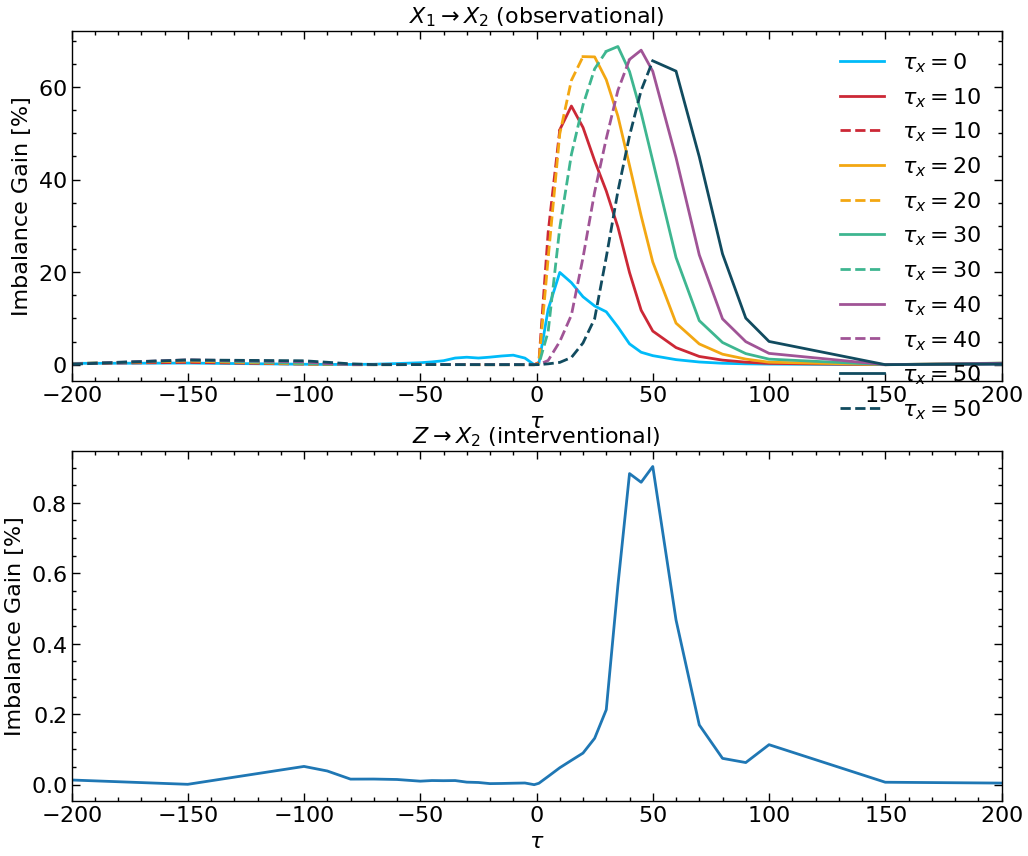

In [15]:
fig, ax = plt.subplots(2,1,figsize=(12,10))

############################### X and Y ###############################
# eps_zx = 0
ax[0].plot(taus, IGs_X_to_Y_obs, '-', color=colors[0], label="$\\tau_x=0$")
ax[0].plot(taus[taus>=10], IGs_X_to_Y_obs_taux10[taus>=10], '-', color=colors[1], label="$\\tau_x=10$")
ax[0].plot(taus[taus<=10], IGs_X_to_Y_obs_taux10[taus<=10], '--', color=colors[1])
ax[0].plot(taus[taus>=20], IGs_X_to_Y_obs_taux20[taus>=20], '-', color=colors[2], label="$\\tau_x=20$")
ax[0].plot(taus[taus<=20], IGs_X_to_Y_obs_taux20[taus<=20], '--', color=colors[2])
ax[0].plot(taus[taus>=30], IGs_X_to_Y_obs_taux30[taus>=30], '-', color=colors[3], label="$\\tau_x=30$")
ax[0].plot(taus[taus<=30], IGs_X_to_Y_obs_taux30[taus<=30], '--', color=colors[3])
ax[0].plot(taus[taus>=40], IGs_X_to_Y_obs_taux40[taus>=40], '-', color=colors[4], label="$\\tau_x=40$")
ax[0].plot(taus[taus<=40], IGs_X_to_Y_obs_taux40[taus<=40], '--', color=colors[4])
ax[0].plot(taus[taus>=50], IGs_X_to_Y_obs_taux50[taus>=50], '-', color=colors[5], label="$\\tau_x=50$")
ax[0].plot(taus[taus<=50], IGs_X_to_Y_obs_taux50[taus<=50], '--', color=colors[5])

ax[0].set(xlabel="$\\tau$", ylabel="Imbalance Gain [%]", xlim=[-200,200], title="$X_{1}\\rightarrow X_{2}$ (observational)")
ax[0].legend()

################################ Z and Y ###############################
# eps_zx = 0
ax[1].plot(taus, IGs_Z_to_Y_eps3, '-', color="tab:blue")
ax[1].set(xlabel="$\\tau$", ylabel="Imbalance Gain [%]", xlim=[-200,200], title="$Z\\rightarrow X_{2}$ (interventional)")
#ax[1].legend()

#plt.savefig("./figures/artificial_delay_X0.pdf", dpi=300)
plt.show()

### Lorenz 96, artificial delay in X(0), x_1 -> x_10

In [15]:
seeds = np.arange(0,31, dtype=int)
alphas = np.linspace(0.,1.5,300)
taus_forward = np.array([1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 60, 70, 80, 90, 100, 150, 200, 250, 300, 350, 400])
taus_backward = -np.flip(taus_forward)
taus = np.append(taus_backward,taus_forward)

# X and Y 10 30 50 70 90 110 130
info_imbalances_X_to_Y_obs = np.zeros((len(seeds)-1,len(taus),len(alphas)))
info_imbalances_X_to_Y_obs_taux10 = np.zeros((len(seeds)-1,len(taus),len(alphas)))
info_imbalances_X_to_Y_obs_taux30 = np.zeros((len(seeds)-1,len(taus),len(alphas)))
info_imbalances_X_to_Y_obs_taux50 = np.zeros((len(seeds)-1,len(taus),len(alphas)))
info_imbalances_X_to_Y_obs_taux70 = np.zeros((len(seeds)-1,len(taus),len(alphas)))
info_imbalances_X_to_Y_obs_taux90 = np.zeros((len(seeds)-1,len(taus),len(alphas)))
info_imbalances_X_to_Y_obs_taux110 = np.zeros((len(seeds)-1,len(taus),len(alphas)))
info_imbalances_X_to_Y_obs_taux130 = np.zeros((len(seeds)-1,len(taus),len(alphas)))
for i_seed, seed in enumerate(np.delete(seeds,2)):
    _, info_imbalances_X_to_Y_obs[i_seed], _ = pickle.load(open(f"./ig_scripts_more_neighbors/pickles_noZ/XY10_seed{seed}.p","rb"))
    _, info_imbalances_X_to_Y_obs_taux10[i_seed] = pickle.load(open(f"./ig_scripts_artificial_delay/pickles_noZ/XY10_taux010_seed{seed}.p","rb"))
    _, info_imbalances_X_to_Y_obs_taux30[i_seed] = pickle.load(open(f"./ig_scripts_artificial_delay/pickles_noZ/XY10_taux030_seed{seed}.p","rb"))
    _, info_imbalances_X_to_Y_obs_taux50[i_seed] = pickle.load(open(f"./ig_scripts_artificial_delay/pickles_noZ/XY10_taux050_seed{seed}.p","rb"))
    _, info_imbalances_X_to_Y_obs_taux70[i_seed] = pickle.load(open(f"./ig_scripts_artificial_delay/pickles_noZ/XY10_taux070_seed{seed}.p","rb"))
    _, info_imbalances_X_to_Y_obs_taux90[i_seed] = pickle.load(open(f"./ig_scripts_artificial_delay/pickles_noZ/XY10_taux090_seed{seed}.p","rb"))
    _, info_imbalances_X_to_Y_obs_taux110[i_seed] = pickle.load(open(f"./ig_scripts_artificial_delay/pickles_noZ/XY10_taux0110_seed{seed}.p","rb"))
    _, info_imbalances_X_to_Y_obs_taux130[i_seed] = pickle.load(open(f"./ig_scripts_artificial_delay/pickles_noZ/XY10_taux0130_seed{seed}.p","rb"))
IGs_X_to_Y_obs, errors_X_to_Y_obs = compute_IGs(info_imbalances_X_to_Y_obs)
IGs_X_to_Y_obs_taux10, errors_X_to_Y_obs_taux10 = compute_IGs(info_imbalances_X_to_Y_obs_taux10)
IGs_X_to_Y_obs_taux30, errors_X_to_Y_obs_taux30 = compute_IGs(info_imbalances_X_to_Y_obs_taux30)
IGs_X_to_Y_obs_taux50, errors_X_to_Y_obs_taux50 = compute_IGs(info_imbalances_X_to_Y_obs_taux50)
IGs_X_to_Y_obs_taux70, errors_X_to_Y_obs_taux70 = compute_IGs(info_imbalances_X_to_Y_obs_taux70)
IGs_X_to_Y_obs_taux90, errors_X_to_Y_obs_taux90 = compute_IGs(info_imbalances_X_to_Y_obs_taux90)
IGs_X_to_Y_obs_taux110, errors_X_to_Y_obs_taux110 = compute_IGs(info_imbalances_X_to_Y_obs_taux110)
IGs_X_to_Y_obs_taux130, errors_X_to_Y_obs_taux130 = compute_IGs(info_imbalances_X_to_Y_obs_taux130)

# Z and Y
info_imbalances_Z_to_Y_eps3 = np.zeros((len(seeds)-1,len(taus),len(alphas)))
for i_seed, seed in enumerate(np.delete(seeds,2)):
    _, info_imbalances_Z_to_Y_eps3[i_seed], _ = pickle.load(open(f"./ig_scripts_more_neighbors/pickles_epszx_3/ZY10_seed{seed}.p","rb"))
IGs_Z_to_Y_eps3, errors_Z_to_Y_eps3 = compute_IGs(info_imbalances_Z_to_Y_eps3)

### plots

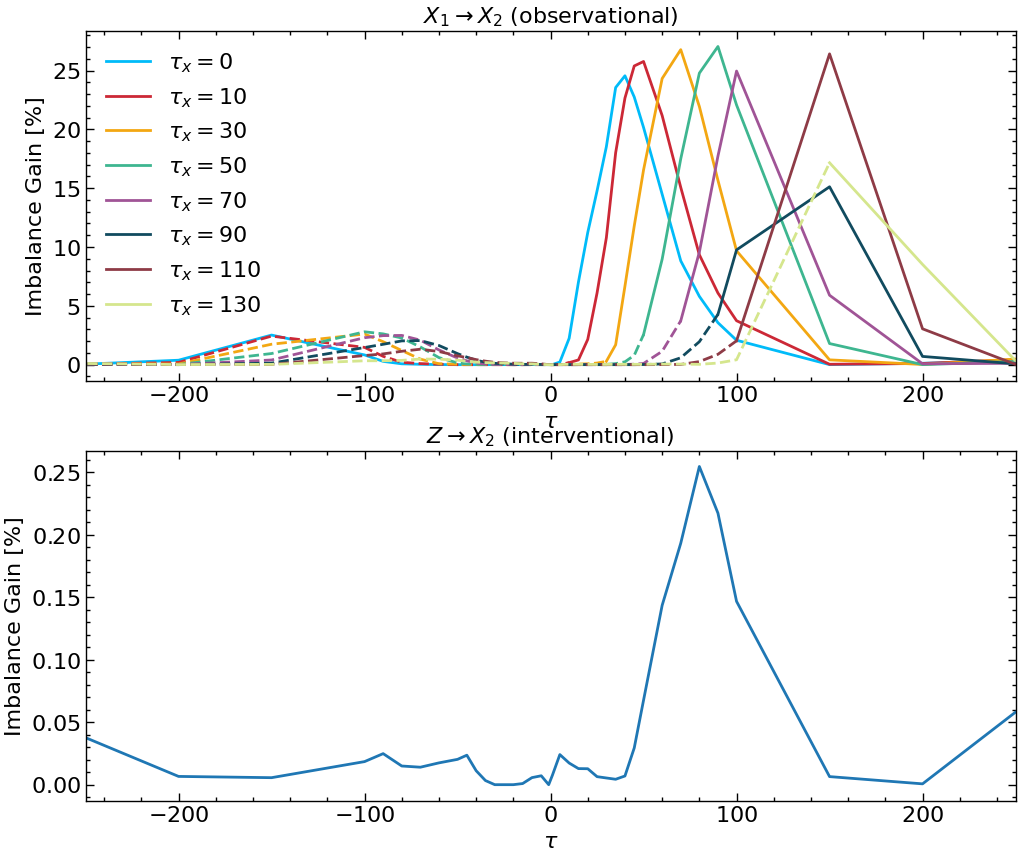

In [21]:
fig, ax = plt.subplots(2,1,figsize=(12,10))

############################### X and Y ###############################
# eps_zx = 0
ax[0].plot(taus, IGs_X_to_Y_obs, '-', color=colors[0], label="$\\tau_x=0$")
ax[0].plot(taus[taus>=10], IGs_X_to_Y_obs_taux10[taus>=10], '-', color=colors[1], label="$\\tau_x=10$")
ax[0].plot(taus[taus<=10], IGs_X_to_Y_obs_taux10[taus<=10], '--', color=colors[1])
ax[0].plot(taus[taus>=30], IGs_X_to_Y_obs_taux30[taus>=30], '-', color=colors[2], label="$\\tau_x=30$")
ax[0].plot(taus[taus<=30], IGs_X_to_Y_obs_taux30[taus<=30], '--', color=colors[2])
ax[0].plot(taus[taus>=50], IGs_X_to_Y_obs_taux50[taus>=50], '-', color=colors[3], label="$\\tau_x=50$")
ax[0].plot(taus[taus<=50], IGs_X_to_Y_obs_taux50[taus<=50], '--', color=colors[3])
ax[0].plot(taus[taus>=70], IGs_X_to_Y_obs_taux70[taus>=70], '-', color=colors[4], label="$\\tau_x=70$")
ax[0].plot(taus[taus<=70], IGs_X_to_Y_obs_taux70[taus<=70], '--', color=colors[4])
ax[0].plot(taus[taus>=90], IGs_X_to_Y_obs_taux90[taus>=90], '-', color=colors[5], label="$\\tau_x=90$")
ax[0].plot(taus[taus<=90], IGs_X_to_Y_obs_taux90[taus<=90], '--', color=colors[5])
ax[0].plot(taus[taus>=100], IGs_X_to_Y_obs_taux110[taus>=100], '-', color=colors[6], label="$\\tau_x=110$")
ax[0].plot(taus[taus<=100], IGs_X_to_Y_obs_taux110[taus<=100], '--', color=colors[6])
ax[0].plot(taus[taus>=150], IGs_X_to_Y_obs_taux130[taus>=150], '-', color=colors[7], label="$\\tau_x=130$")
ax[0].plot(taus[taus<=150], IGs_X_to_Y_obs_taux130[taus<=150], '--', color=colors[7])

ax[0].set(xlabel="$\\tau$", ylabel="Imbalance Gain [%]", xlim=[-250,250], title="$X_{1}\\rightarrow X_{2}$ (observational)")
ax[0].legend()

################################ Z and Y ###############################
# eps_zx = 0
ax[1].plot(taus, IGs_Z_to_Y_eps3, '-', color="tab:blue")
ax[1].fill_between(taus, IGs_Z_to_Y_eps3-errors_Z_to_Y_eps3, 
                         IGs_Z_to_Y_eps3+errors_Z_to_Y_eps3, color=colors[1], alpha=0.15)
ax[1].set(xlabel="$\\tau$", ylabel="Imbalance Gain [%]", xlim=[-250,250], title="$Z\\rightarrow X_{2}$ (interventional)")
#ax[1].legend()

plt.savefig("./figures/artificial_delay_X0_Y10.pdf", dpi=300)
plt.show()